In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import string
import warnings
import os
import time
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

# Download required NLTK resources
for resource in ['stopwords', 'wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(resource, quiet=True)

print('All imports successful ✓')

All imports successful ✓


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
DATA_PATH = '../dataset.csv'   # update path if needed
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
df.head(3)

Dataset shape : (50000, 2)
Columns       : ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [3]:
# ── Null check ────────────────────────────────────────────────────────────────
print('=== Null Values ===')
print(df.isnull().sum())

# ── Duplicate check ───────────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f'\nDuplicate rows : {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'After dedup    : {df.shape}')

# ── Data types ────────────────────────────────────────────────────────────────
print('\n=== Data Types ===')
print(df.dtypes)

=== Null Values ===
review       0
sentiment    0
dtype: int64

Duplicate rows : 418
After dedup    : (49582, 2)

=== Data Types ===
review       str
sentiment    str
dtype: object


=== Class Distribution ===
sentiment
positive    24884
negative    24698
Name: count, dtype: int64

Balance ratio  : 0.993  (1.0 = perfectly balanced)


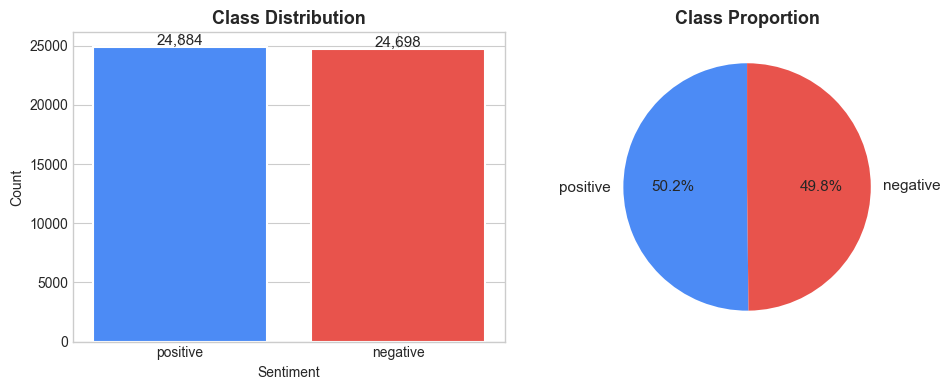

✓ Saved: eda_class_distribution.png


In [4]:
label_counts = df['sentiment'].value_counts()
print('=== Class Distribution ===')
print(label_counts)
print(f'\nBalance ratio  : {label_counts.min()/label_counts.max():.3f}  (1.0 = perfectly balanced)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ['#4C8BF5', '#E8534C']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, (cat, val) in enumerate(label_counts.items()):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: eda_class_distribution.png')

=== Review Length Statistics ===
          word_count                                                  char_count                                                     
               count   mean    std   min    25%    50%    75%     max      count    mean     std   min    25%    50%     75%      max
sentiment                                                                                                                            
negative     24698.0  229.6  165.1   4.0  128.0  174.0  278.0  1522.0    24698.0  1294.7   946.5  32.0  706.0  974.0  1568.0   8969.0
positive     24884.0  233.1  177.7  10.0  125.0  172.0  284.0  2470.0    24884.0  1326.3  1032.6  65.0  692.0  969.0  1615.2  13704.0


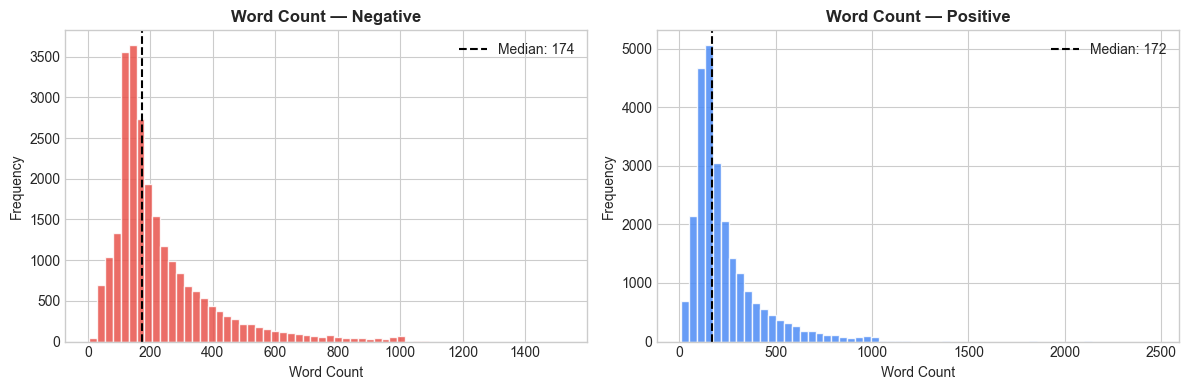

✓ Saved: eda_review_length.png


In [5]:
df['word_count']  = df['review'].str.split().str.len()
df['char_count']  = df['review'].str.len()

print('=== Review Length Statistics ===')
print(df.groupby('sentiment')[['word_count', 'char_count']].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, grp) in zip(axes, df.groupby('sentiment')):
    color = '#4C8BF5' if label == 'positive' else '#E8534C'
    ax.hist(grp['word_count'], bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(grp['word_count'].median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {grp["word_count"].median():.0f}')
    ax.set_title(f'Word Count — {label.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_review_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: eda_review_length.png')

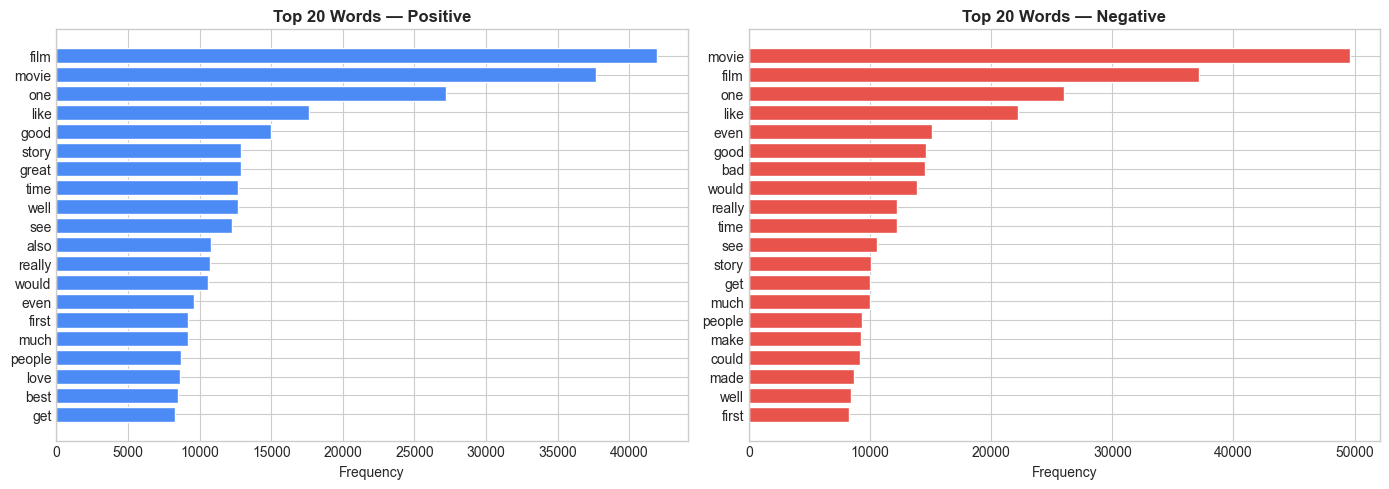

✓ Saved: eda_top_words.png


In [6]:
STOPWORDS = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    """Return top-n words after basic cleaning (no lemmatization yet — raw signal)."""
    all_words = []
    for text in texts:
        text = re.sub(r'<[^>]+>', ' ', text).lower()
        tokens = re.findall(r'[a-z]+', text)
        all_words.extend([t for t in tokens if t not in STOPWORDS and len(t) > 2])
    return Counter(all_words).most_common(n)

pos_words = get_top_words(df[df['sentiment'] == 'positive']['review'])
neg_words = get_top_words(df[df['sentiment'] == 'negative']['review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, words, color, title in zip(
    axes,
    [pos_words, neg_words],
    ['#4C8BF5', '#E8534C'],
    ['Top 20 Words — Positive', 'Top 20 Words — Negative']
):
    labels, vals = zip(*words)
    ax.barh(labels[::-1], vals[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: eda_top_words.png')

In [7]:
html_mask = df['review'].str.contains(r'<[^>]+>', regex=True)
print(f'Reviews containing HTML tags : {html_mask.sum():,}  ({html_mask.mean()*100:.1f}%)')
print('\nSample HTML-containing review (first 200 chars):')
print(df[html_mask]['review'].iloc[0][:200])

Reviews containing HTML tags : 28,968  (58.4%)

Sample HTML-containing review (first 200 chars):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo


In [8]:
print(f'Avg word count (raw) : {df["word_count"].mean():.1f}')
print(f'Max word count (raw) : {df["word_count"].max()}')
print(f'Min word count (raw) : {df["word_count"].min()}')

Avg word count (raw) : 231.4
Max word count (raw) : 2470
Min word count (raw) : 4


In [9]:
df['label'] = (df['sentiment'] == 'positive').astype(int)

print('Label mapping  : positive → 1 | negative → 0')
print(df['label'].value_counts())
df[['review', 'sentiment', 'label']].head(3)

Label mapping  : positive → 1 | negative → 0
label
1    24884
0    24698
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


In [10]:
STOP_WORDS = set(stopwords.words('english'))
NEGATIONS = {
    'not', 'no', 'nor', 'never'
}

STOP_WORDS = STOP_WORDS - NEGATIONS
LEMMATIZER  = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Full text cleaning pipeline for IMDb reviews."""
    # 1. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # 3. Lowercase
    text = text.lower()
    # 4. Keep only alphabetic characters and apostrophes
    text = re.sub(r"[^a-z'\s]", ' ', text)
    # 5. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 6. Tokenize
        # 6. Tokenize
    tokens = text.split()
    
    # 7 & 8. Remove stop words, short tokens, AND lemmatize
    tokens = [
        LEMMATIZER.lemmatize(t) 
        for t in tokens 
        if t not in STOP_WORDS and len(t) > 2
    ]
    
    return ' '.join(tokens)

# ── Sanity check on one example ───────────────────────────────────────────────
sample_idx = 0
raw   = df['review'].iloc[sample_idx]
clean = clean_text(raw)
print('=== Cleaning Demo ===')
print(f'RAW    ({len(raw.split())} words): {raw[:200]}...')
print()
print(f'CLEAN  ({len(clean.split())} words): {clean[:200]}...')

=== Cleaning Demo ===
RAW    (307 words): One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

CLEAN  (159 words): one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust not show faint hearted timid show pull punch regard d...


In [11]:
# ── Apply to full dataset ─────────────────────────────────────────────────────
print('Cleaning 50,000 reviews...')
t0 = time.time()
df['cleaned'] = df['review'].apply(clean_text)
elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s')

df['cleaned_word_count'] = df['cleaned'].str.split().str.len()

print(f'\nAvg word count  →  Raw: {df["word_count"].mean():.1f}  |  Cleaned: {df["cleaned_word_count"].mean():.1f}')
print(f'Vocabulary reduction : {(1 - df["cleaned_word_count"].mean()/df["word_count"].mean())*100:.1f}%')

# Check for empty reviews after cleaning
empty = (df['cleaned'].str.strip() == '').sum()
print(f'Empty after cleaning : {empty}')
if empty > 0:
    df = df[df['cleaned'].str.strip() != ''].reset_index(drop=True)
    print(f'Removed {empty} empty rows. New shape: {df.shape}')

Cleaning 50,000 reviews...
Done in 75.1s

Avg word count  →  Raw: 231.4  |  Cleaned: 118.5
Vocabulary reduction : 48.8%
Empty after cleaning : 0


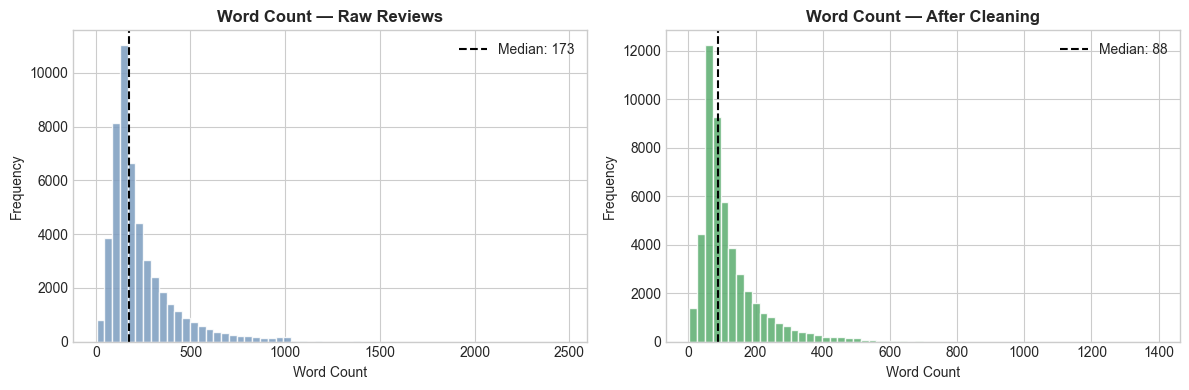

✓ Saved: eda_before_after_cleaning.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['word_count'], bins=60, color='#7C9CBF', edgecolor='white', alpha=0.85)
axes[0].set_title('Word Count — Raw Reviews', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['word_count'].median(), color='black', linestyle='--',
                label=f'Median: {df["word_count"].median():.0f}')
axes[0].legend()

axes[1].hist(df['cleaned_word_count'], bins=60, color='#5BAD6F', edgecolor='white', alpha=0.85)
axes[1].set_title('Word Count — After Cleaning', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['cleaned_word_count'].median(), color='black', linestyle='--',
                label=f'Median: {df["cleaned_word_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_before_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: eda_before_after_cleaning.png')

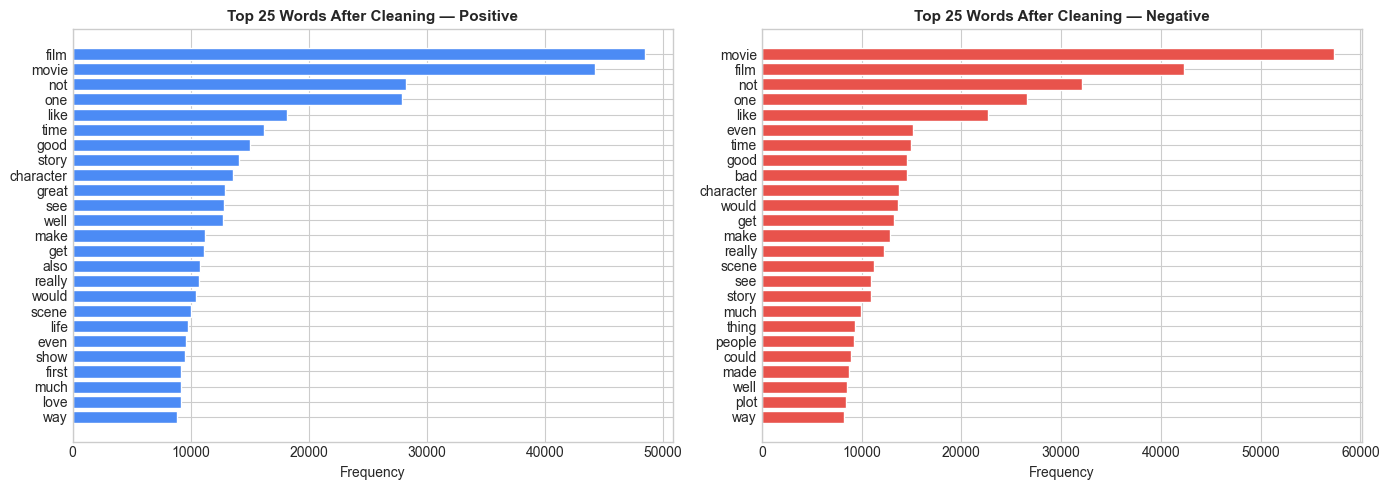

✓ Saved: eda_top_words_cleaned.png


In [13]:
def get_top_cleaned(texts, n=25):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

pos_clean_words = get_top_cleaned(df[df['label']==1]['cleaned'])
neg_clean_words = get_top_cleaned(df[df['label']==0]['cleaned'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, words, color, title in zip(
    axes,
    [pos_clean_words, neg_clean_words],
    ['#4C8BF5', '#E8534C'],
    ['Top 25 Words After Cleaning — Positive', 'Top 25 Words After Cleaning — Negative']
):
    labels, vals = zip(*words)
    ax.barh(labels[::-1], vals[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('eda_top_words_cleaned.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: eda_top_words_cleaned.png')

In [14]:
# .to_numpy(dtype=str) avoids pyarrow-backend indexing errors with sklearn
X = df['cleaned'].to_numpy(dtype=str)
y = df['label'].to_numpy(dtype=int)

# Step 1: 85% train+val | 15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Step 2: 70/85 train | 15/85 val  ≈  82.4% / 17.6% of trainval
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=SEED, stratify=y_trainval
)

print('=== Split Summary ===')
for name, X_s, y_s in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    pos = y_s.sum(); neg = len(y_s) - pos
    print(f'{name:5s}: {len(X_s):6,} samples  |  pos: {pos:,}  neg: {neg:,}  ratio: {pos/len(y_s):.3f}')

=== Split Summary ===
Train: 34,706 samples  |  pos: 17,418  neg: 17,288  ratio: 0.502
Val  :  7,438 samples  |  pos: 3,733  neg: 3,705  ratio: 0.502
Test :  7,438 samples  |  pos: 3,733  neg: 3,705  ratio: 0.502


Pearson correlation (text_length vs label): 0.0188
Interpretation: small but can be useful as an auxiliary feature in Phase 2


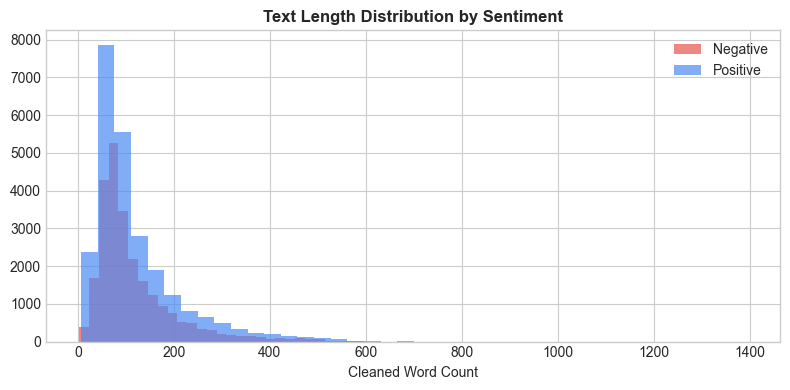

✓ Saved: eda_length_by_sentiment.png


In [15]:
df['text_length'] = df['cleaned'].str.split().str.len()

# Check correlation with label
corr = df['text_length'].corr(df['label'])
print(f'Pearson correlation (text_length vs label): {corr:.4f}')
print('Interpretation: small but can be useful as an auxiliary feature in Phase 2')

fig, ax = plt.subplots(figsize=(8, 4))
colors_map = {'positive': '#4C8BF5', 'negative': '#E8534C'}
for sentiment, grp in df.groupby('sentiment'):
    ax.hist(grp['text_length'], bins=40, alpha=0.7,
            color=colors_map[sentiment], label=sentiment.capitalize())
ax.set_xlabel('Cleaned Word Count')
ax.set_title('Text Length Distribution by Sentiment', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_length_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: eda_length_by_sentiment.png')

In [16]:
os.makedirs('data', exist_ok=True)

# Save full cleaned dataframe
df[['review', 'cleaned', 'sentiment', 'label', 'word_count', 'cleaned_word_count', 'text_length']].to_csv(
    'data/imdb_cleaned.csv', index=False
)
print('✓ Saved: data/imdb_cleaned.csv')

# Save splits as numpy arrays (faster loading in Phase 2)
np.save('data/X_train.npy', X_train)
np.save('data/X_val.npy',   X_val)
np.save('data/X_test.npy',  X_test)
np.save('data/y_train.npy', y_train)
np.save('data/y_val.npy',   y_val)
np.save('data/y_test.npy',  y_test)
print('✓ Saved: data/X_train.npy, X_val.npy, X_test.npy, y_train.npy, y_val.npy, y_test.npy')

print(f'\n=== Phase 1 Complete ===')
print(f'Total samples : {len(df):,}')
print(f'Train         : {len(X_train):,}')
print(f'Validation    : {len(X_val):,}')
print(f'Test          : {len(X_test):,} (locked — do not touch until final evaluation)')

✓ Saved: data/imdb_cleaned.csv
✓ Saved: data/X_train.npy, X_val.npy, X_test.npy, y_train.npy, y_val.npy, y_test.npy

=== Phase 1 Complete ===
Total samples : 49,582
Train         : 34,706
Validation    : 7,438
Test          : 7,438 (locked — do not touch until final evaluation)
